# Uber Fare Prediction — Data Analysis & Preprocessing

End-to-end notebook: load data → EDA → drop irrelevant columns → handle missing values → reorder columns → encode categorical columns (ordinal + one-hot) → convert data types → prepare final feature matrix for model training.

## 1. Import Libraries

Core libraries for data handling (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and preprocessing utilities from `scikit-learn`.

In [288]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)

## 2. Load Data

Read the raw CSV file and take a first look at its structure.

In [289]:
data = pd.read_csv('../data/input_dataset.csv')
data.head()

,City,Pickup Location,Drop Location,Distance (km),Vehicle Type,Estimated Duration (min),Pickup Latitude,Pickup Longitude,Drop Latitude,Drop Longitude,Pickup Area Type,Drop Area Type,Weather Condition,Temperature Level,Rainfall Intensity,Traffic Level,Road Type,Number of Stops Added,Time Slot,Day Type,Holiday,Busy Day,Trip Date,Fare (Target)
0,Pune,Viman Nagar,Pimpri,150.44,Sedan,429.9,18.5679,73.9143,18.6298,73.7997,Residential,Commercial,Clear,Very Hot,NaN,Moderate,City Road,0.0,Midday,Weekday,No,Normal,8/18/2025,2178
1,Chennai,Chennai Central Railway Station (nearby),Koyambedu (CMBT) Bus Stand (nearby),380.34,Sedan,497.3,13.0879,80.2578,13.0764,80.1995,Railway Station,Bus Stand,Clear,Pleasant,NaN,Severe,Highway,0.0,Late Night,Weekday,Yes,Public Holiday,4/23/2025,5679
2,Pune -> Mumbai,Koregaon Park,Shivajinagar Railway Station,293.07,Sedan,769.7,18.5362,73.8938,18.5308,73.8475,Residential,Railway Station,Cloudy,Warm,NaN,Moderate,City Road,4.0,Night,Weekday,Yes,Normal,10/20/2025,4182
3,Pune -> Mumbai,Fergusson College,Vanaz Metro Station,239.86,Black,306.9,18.5236,73.8380,18.5023,73.8074,College,Metro Station,Rain,Pleasant,Light,Severe,Highway,0.0,Midday,Weekday,Yes,Normal,1/10/2025,6811
4,Pune,Pimpri,Koregaon Park,63.25,Sedan,123.6,18.6298,73.7997,18.5362,73.8938,Commercial,Residential,Clear,Pleasant,NaN,Low,City Road,0.0,Evening,Weekday,No,Normal,12/22/2025,943


## 3. Basic Observations (EDA)

Check shape, data types, and non-null counts to understand what we're working with before any cleaning.

In [290]:
print("Shape:", data.shape)
data.info()

Shape: (5792, 24)
<class 'pandas.DataFrame'>
RangeIndex: 5792 entries, 0 to 5791
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   City                      5777 non-null   str    
 1   Pickup Location           5770 non-null   str    
 2   Drop Location             5778 non-null   str    
 3   Distance (km)             5792 non-null   float64
 4   Vehicle Type              5769 non-null   str    
 5   Estimated Duration (min)  5792 non-null   float64
 6   Pickup Latitude           5772 non-null   float64
 7   Pickup Longitude          5781 non-null   float64
 8   Drop Latitude             5772 non-null   float64
 9   Drop Longitude            5773 non-null   float64
 10  Pickup Area Type          5775 non-null   str    
 11  Drop Area Type            5774 non-null   str    
 12  Weather Condition         5775 non-null   str    
 13  Temperature Level         5778 non-null   str    
 14  R

### Duplicate rows

Check for and remove exact duplicate rows, since they add no new information and can bias the model.

In [291]:
print("Duplicate rows:", data.duplicated().sum())
data.drop_duplicates(inplace=True)
print("Shape after dropping duplicates:", data.shape)

Duplicate rows: 0
Shape after dropping duplicates: (5792, 24)


### Numeric column summary

`describe()` shows the range, mean, and spread of numeric columns — useful for spotting outliers (e.g. unusually large distances or zero fares).

In [292]:
data.describe()

,Distance (km),Estimated Duration (min),Pickup Latitude,Pickup Longitude,Drop Latitude,Drop Longitude,Number of Stops Added,Fare (Target)
count,5792.000000,5792.000000,5772.000000,5781.000000,5772.000000,5773.000000,5778.000000,5792.000000
mean,199.221526,381.722376,17.887043,76.411700,17.873694,76.417035,1.058844,2870.679040
std,115.472619,359.977270,4.986757,2.523552,5.003611,2.529964,1.349064,1755.956798
min,1.000000,1.000000,11.941600,72.805000,11.016800,72.805000,0.000000,188.000000
25%,99.127500,132.300000,13.010800,73.841200,13.007800,73.841200,0.000000,1507.500000
50%,199.815000,266.050000,18.502300,77.227300,18.502300,77.219700,1.000000,2650.000000
75%,298.715000,521.475000,19.059600,78.348900,19.062600,78.382100,2.000000,3860.250000
max,399.890000,2273.200000,28.760100,80.270700,30.733300,80.648000,6.000000,12046.000000


### Categorical column overview

List the unique categories in each categorical column. This confirms exactly what values exist (and what we'll need mappings for later in the encoding step).

In [293]:
categorical_cols = ['Vehicle Type', 'Pickup Area Type', 'Drop Area Type', 'Weather Condition',
                    'Temperature Level', 'Rainfall Intensity', 'Traffic Level', 'Road Type',
                    'Time Slot', 'Day Type', 'Holiday', 'Busy Day']

for col in categorical_cols:
    print(f"{col} ({data[col].nunique()} categories):", sorted(data[col].dropna().unique().tolist()))
    print()

Vehicle Type (11 categories): ['Auto', 'Bike', 'Black', 'Comfort', 'Go', 'Mini', 'Pool', 'Premium', 'SUV', 'Sedan', 'XL']

Pickup Area Type (10 categories): ['Airport', 'Bus Stand', 'College', 'Commercial', 'Hospital', 'IT Park', 'Mall', 'Metro Station', 'Railway Station', 'Residential']

Drop Area Type (10 categories): ['Airport', 'Bus Stand', 'College', 'Commercial', 'Hospital', 'IT Park', 'Mall', 'Metro Station', 'Railway Station', 'Residential']

Weather Condition (6 categories): ['Clear', 'Cloudy', 'Fog', 'Heavy Rain', 'Rain', 'Storm']

Temperature Level (5 categories): ['Cold', 'Hot', 'Pleasant', 'Very Hot', 'Warm']

Rainfall Intensity (3 categories): ['Heavy', 'Light', 'Moderate']

Traffic Level (4 categories): ['High', 'Low', 'Moderate', 'Severe']

Road Type (4 categories): ['City Road', 'Expressway', 'Highway', 'Rural Road']

Time Slot (7 categories): ['Evening', 'Evening Rush', 'Late Night', 'Midday', 'Morning', 'Morning Rush', 'Night']

Day Type (2 categories): ['Weekday', '

### Missing values overview

Check how many missing values exist in each column before deciding how to handle them.

In [294]:
data.isnull().sum()

City                          15
Pickup Location               22
Drop Location                 14
Distance (km)                  0
Vehicle Type                  23
Estimated Duration (min)       0
Pickup Latitude               20
Pickup Longitude              11
Drop Latitude                 20
Drop Longitude                19
Pickup Area Type              17
Drop Area Type                18
Weather Condition             17
Temperature Level             14
Rainfall Intensity          4629
Traffic Level                 18
Road Type                     22
Number of Stops Added         14
Time Slot                     17
Day Type                      15
Holiday                       16
Busy Day                      14
Trip Date                     19
Fare (Target)                  0
dtype: int64

### Target variable distribution

Visualize `Fare (Target)` to check its distribution/skew — this matters later if a log transform is needed for modeling.

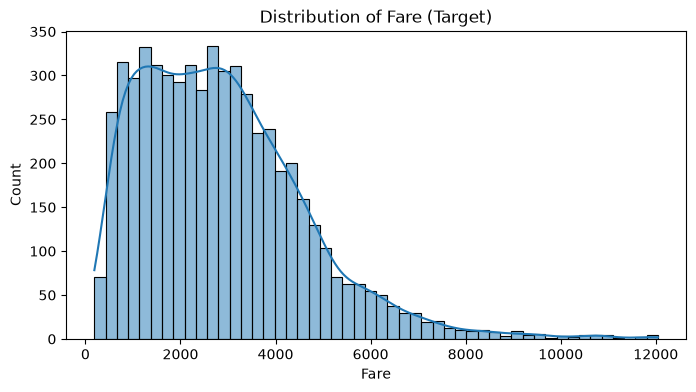

In [295]:
plt.figure(figsize=(8,4))
sns.histplot(data['Fare (Target)'], bins=50, kde=True)
plt.title('Distribution of Fare (Target)')
plt.xlabel('Fare')
plt.show()

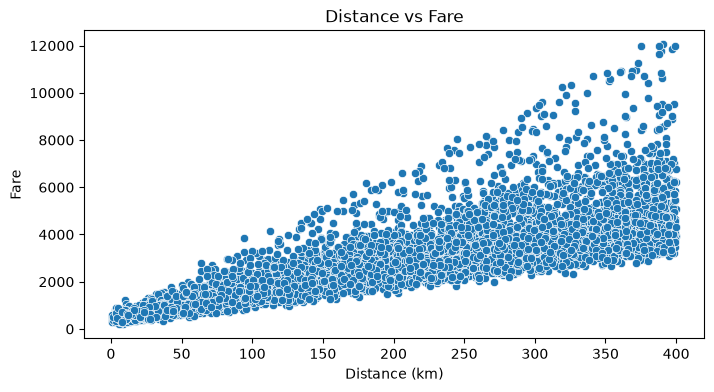

In [296]:
 

plt.figure(figsize=(8,4))

sns.scatterplot(
    data=data,
    x="Distance (km)",
    y="Fare (Target)"
)

plt.title("Distance vs Fare")
plt.xlabel("Distance (km)")
plt.ylabel("Fare")
plt.show()

## 4. Drop Unnecessary Columns

We keep only the columns relevant for model training and drop the rest:

- **`City`** — dropped; effect is already reflected through Area Type / Distance / Duration patterns.
- **`Pickup Location`, `Drop Location`** — near-unique text identifiers (~200+ distinct values). A model can't generalize from raw address text, and they add overfitting/leakage risk. The useful signal from these is already captured by `Pickup/Drop Area Type` and `Distance (km)`.
- **`Pickup Latitude`, `Pickup Longitude`, `Drop Latitude`, `Drop Longitude`** — raw coordinates had near-zero correlation with fare; dropped in favor of `Distance (km)`, which already encodes the geographic relationship.
- **`Trip Date`** — raw date is a near-unique identifier with no direct generalizable value; dropped here since we're not extracting seasonality features in this version.

**Final feature set kept:** `Distance (km)`, `Vehicle Type`, `Estimated Duration (min)`, `Pickup Area Type`, `Drop Area Type`, `Weather Condition`, `Temperature Level`, `Rainfall Intensity`, `Traffic Level`, `Road Type`, `Number of Stops Added`, `Time Slot`, `Day Type`, `Holiday`, `Busy Day`, `Fare (Target)`.

In [297]:
keep_cols = ['Distance (km)', 'Vehicle Type', 'Estimated Duration (min)', 'Pickup Area Type',
             'Drop Area Type', 'Weather Condition', 'Temperature Level', 'Rainfall Intensity',
             'Traffic Level', 'Road Type', 'Number of Stops Added', 'Time Slot', 'Day Type',
             'Holiday', 'Busy Day', 'Fare (Target)']

data = data[keep_cols]
data.shape

(5792, 16)

## 5. Reorder Columns (by predictive strength)

Order columns from strongest to weakest effect on fare (based on correlation for numeric columns, and group-mean spread for categorical columns), with the target column placed last — this is standard convention and makes later `X`/`y` splitting trivial.

In [298]:
column_order = [
    'Distance (km)',
    'Estimated Duration (min)',
    'Weather Condition',
    'Rainfall Intensity',
    'Traffic Level',
    'Vehicle Type',
    'Road Type',
    'Time Slot',
    'Temperature Level',
    'Busy Day',
    'Holiday',
    'Pickup Area Type',
    'Day Type',
    'Drop Area Type',
    'Number of Stops Added',
    'Fare (Target)'
]

data = data[column_order]
data.head()

,Distance (km),Estimated Duration (min),Weather Condition,Rainfall Intensity,Traffic Level,Vehicle Type,Road Type,Time Slot,Temperature Level,Busy Day,Holiday,Pickup Area Type,Day Type,Drop Area Type,Number of Stops Added,Fare (Target)
0,150.44,429.9,Clear,NaN,Moderate,Sedan,City Road,Midday,Very Hot,Normal,No,Residential,Weekday,Commercial,0.0,2178
1,380.34,497.3,Clear,NaN,Severe,Sedan,Highway,Late Night,Pleasant,Public Holiday,Yes,Railway Station,Weekday,Bus Stand,0.0,5679
2,293.07,769.7,Cloudy,NaN,Moderate,Sedan,City Road,Night,Warm,Normal,Yes,Residential,Weekday,Railway Station,4.0,4182
3,239.86,306.9,Rain,Light,Severe,Black,Highway,Midday,Pleasant,Normal,Yes,College,Weekday,Metro Station,0.0,6811
4,63.25,123.6,Clear,NaN,Low,Sedan,City Road,Evening,Pleasant,Normal,No,Commercial,Weekday,Residential,0.0,943


## 6. Handle Missing Values

Different strategies for different column types:

- **Numeric columns** (`Distance (km)`, `Estimated Duration (min)`, `Number of Stops Added`) → fill with **median** (robust to outliers).
- **`Rainfall Intensity`** → missing here mostly means "it wasn't raining," so filled with the explicit category `'No Rain'` rather than a generic mode.
- **All other categorical columns** → fill with the **mode** (most frequent category), a safe default when missingness looks random rather than meaningful.

In [299]:
# Numeric columns -> median
numeric_cols = ['Distance (km)', 'Estimated Duration (min)', 'Number of Stops Added']
for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

# Rainfall Intensity -> explicit 'No Rain' category
data['Rainfall Intensity'] = data['Rainfall Intensity'].fillna('No Rain')

# Remaining categorical columns -> mode
mode_fill_cols = ['Weather Condition', 'Traffic Level', 'Vehicle Type', 'Road Type', 'Time Slot',
                   'Temperature Level', 'Busy Day', 'Holiday', 'Pickup Area Type', 'Day Type',
                   'Drop Area Type']
for col in mode_fill_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# Verify no missing values remain
data.isnull().sum()

Distance (km)               0
Estimated Duration (min)    0
Weather Condition           0
Rainfall Intensity          0
Traffic Level               0
Vehicle Type                0
Road Type                   0
Time Slot                   0
Temperature Level           0
Busy Day                    0
Holiday                     0
Pickup Area Type            0
Day Type                    0
Drop Area Type              0
Number of Stops Added       0
Fare (Target)               0
dtype: int64

## 7. Categorical Encoding

Two different encoding strategies are used, depending on whether a column's categories have a natural order:

### A. Ordinal Encoding (order matters → map to 0, 1, 2, ...)
| Column | Order used |
|---|---|
| `Weather Condition` | Clear(0) < Cloudy(1) < Fog(2) < Rain(3) < Heavy Rain(4) < Storm(5) |
| `Rainfall Intensity` | No Rain(0) < Light(1) < Moderate(2) < Heavy(3) |
| `Traffic Level` | Low(0) < Moderate(1) < High(2) < Severe(3) |
| `Temperature Level` | Cold(0) < Pleasant(1) < Warm(2) < Hot(3) < Very Hot(4) |

### B. Binary Encoding (Yes/No, Weekday/Weekend → 0/1)
| Column | Mapping |
|---|---|
| `Day Type` | Weekday → 0, Weekend → 1 |
| `Holiday` | No → 0, Yes → 1 |

### C. One-Hot Encoding (no natural order → new binary column per category)
| Column | Reason |
|---|---|
| `Vehicle Type` | Product tiers (Bike, Auto, Sedan, SUV, XL, Mini, Premium, Comfort, Go, Pool, Black) — not on a single ordered scale |
| `Road Type` | City Road, Highway, Expressway, Rural Road — different in kind, not degree |
| `Pickup Area Type` | Residential, Airport, Mall, Hospital, etc. — no ranking between area types |
| `Drop Area Type` | Same reasoning as Pickup Area Type |
| `Time Slot` | Morning, Midday, Evening, Night, etc. — cyclical, not linearly ordered |
| `Busy Day` | Normal, Festival, Major Event, Public Holiday — distinct categories, not a scale |

In [300]:
# --- A. Ordinal Encoding ---
weather_order = {'Clear': 0, 'Cloudy': 1, 'Fog': 2, 'Rain': 3, 'Heavy Rain': 4, 'Storm': 5}
data['Weather Condition'] = data['Weather Condition'].map(weather_order)

rain_order = {'No Rain': 0, 'Light': 1, 'Moderate': 2, 'Heavy': 3}
data['Rainfall Intensity'] = data['Rainfall Intensity'].map(rain_order)

traffic_order = {'Low': 0, 'Moderate': 1, 'High': 2, 'Severe': 3}
data['Traffic Level'] = data['Traffic Level'].map(traffic_order)

temp_order = {'Cold': 0, 'Pleasant': 1, 'Warm': 2, 'Hot': 3, 'Very Hot': 4}
data['Temperature Level'] = data['Temperature Level'].map(temp_order)

# --- B. Binary Encoding ---
data['Day Type'] = data['Day Type'].map({'Weekday': 0, 'Weekend': 1})
data['Holiday'] = data['Holiday'].map({'No': 0, 'Yes': 1})

data.head()

,Distance (km),Estimated Duration (min),Weather Condition,Rainfall Intensity,Traffic Level,Vehicle Type,Road Type,Time Slot,Temperature Level,Busy Day,Holiday,Pickup Area Type,Day Type,Drop Area Type,Number of Stops Added,Fare (Target)
0,150.44,429.9,0,0,1,Sedan,City Road,Midday,4,Normal,0,Residential,0,Commercial,0.0,2178
1,380.34,497.3,0,0,3,Sedan,Highway,Late Night,1,Public Holiday,1,Railway Station,0,Bus Stand,0.0,5679
2,293.07,769.7,1,0,1,Sedan,City Road,Night,2,Normal,1,Residential,0,Railway Station,4.0,4182
3,239.86,306.9,3,1,3,Black,Highway,Midday,1,Normal,1,College,0,Metro Station,0.0,6811
4,63.25,123.6,0,0,0,Sedan,City Road,Evening,1,Normal,0,Commercial,0,Residential,0.0,943


### One-Hot Encoding

Apply `pd.get_dummies()` to the nominal columns. `drop_first=True` drops one category per column (the alphabetically-first one) to avoid the dummy-variable trap (multicollinearity) — that dropped category becomes the implied "baseline" when all its dummy columns are 0.

**Resulting column names for each vehicle type** (after `drop_first=True` drops `Vehicle Type_Auto` as the baseline):
`Vehicle Type_Bike`, `Vehicle Type_Black`, `Vehicle Type_Comfort`, `Vehicle Type_Go`, `Vehicle Type_Mini`, `Vehicle Type_Pool`, `Vehicle Type_Premium`, `Vehicle Type_SUV`, `Vehicle Type_Sedan`, `Vehicle Type_XL`

**Other one-hot columns produced:**
- `Road Type` → `Road Type_Expressway`, `Road Type_Highway`, `Road Type_Rural Road` (baseline: City Road)
- `Pickup Area Type` → `Pickup Area Type_Bus Stand`, `Pickup Area Type_College`, `Pickup Area Type_Commercial`, `Pickup Area Type_Hospital`, `Pickup Area Type_IT Park`, `Pickup Area Type_Mall`, `Pickup Area Type_Metro Station`, `Pickup Area Type_Railway Station`, `Pickup Area Type_Residential` (baseline: Airport)
- `Drop Area Type` → same 9 category columns as above, prefixed `Drop Area Type_` (baseline: Airport)
- `Time Slot` → `Time Slot_Evening Rush`, `Time Slot_Late Night`, `Time Slot_Midday`, `Time Slot_Morning`, `Time Slot_Morning Rush`, `Time Slot_Night` (baseline: Evening)
- `Busy Day` → `Busy Day_Major Event`, `Busy Day_Normal`, `Busy Day_Public Holiday` (baseline: Festival)

In [301]:
onehot_cols = ['Vehicle Type', 'Road Type', 'Pickup Area Type', 'Drop Area Type', 'Time Slot', 'Busy Day']

data = pd.get_dummies(data, columns=onehot_cols, drop_first=True)
print("Shape after one-hot encoding:", data.shape)
data.head()

Shape after one-hot encoding: (5792, 50)


,Distance (km),Estimated Duration (min),Weather Condition,Rainfall Intensity,Traffic Level,Temperature Level,Holiday,Day Type,Number of Stops Added,Fare (Target),Vehicle Type_Bike,Vehicle Type_Black,Vehicle Type_Comfort,Vehicle Type_Go,Vehicle Type_Mini,Vehicle Type_Pool,Vehicle Type_Premium,Vehicle Type_SUV,Vehicle Type_Sedan,Vehicle Type_XL,Road Type_Expressway,Road Type_Highway,Road Type_Rural Road,Pickup Area Type_Bus Stand,Pickup Area Type_College,Pickup Area Type_Commercial,Pickup Area Type_Hospital,Pickup Area Type_IT Park,Pickup Area Type_Mall,Pickup Area Type_Metro Station,Pickup Area Type_Railway Station,Pickup Area Type_Residential,Drop Area Type_Bus Stand,Drop Area Type_College,Drop Area Type_Commercial,Drop Area Type_Hospital,Drop Area Type_IT Park,Drop Area Type_Mall,Drop Area Type_Metro Station,Drop Area Type_Railway Station,Drop Area Type_Residential,Time Slot_Evening Rush,Time Slot_Late Night,Time Slot_Midday,Time Slot_Morning,Time Slot_Morning Rush,Time Slot_Night,Busy Day_Major Event,Busy Day_Normal,Busy Day_Public Holiday
0,150.44,429.9,0,0,1,4,0,0,0.0,2178,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
1,380.34,497.3,0,0,3,1,1,0,0.0,5679,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
2,293.07,769.7,1,0,1,2,1,0,4.0,4182,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False
3,239.86,306.9,3,1,3,1,1,0,0.0,6811,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False
4,63.25,123.6,0,0,0,1,0,0,0.0,943,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False


## 8. Data Type Conversion

Convert every column to `int` **except** `Distance (km)`, `Estimated Duration (min)`, and `Fare (Target)`, which stay as `float` (they're continuous, precise measurements). This covers:
- The ordinal-encoded columns (may be `float64` after `.map()`)
- The one-hot dummy columns (`bool` by default from `get_dummies`)
- `Number of Stops Added` and the binary-encoded columns

We check for any leftover nulls first — `.astype(int)` will raise an error if NaN is still present.

In [302]:
exclude_cols = ['Distance (km)', 'Estimated Duration (min)', 'Fare (Target)']

# Safety check: make sure there are no NaNs left in the columns we're about to convert
null_check = data.drop(columns=exclude_cols).isnull().sum()
print(null_check[null_check > 0])   # should print nothing (empty)

Series([], dtype: int64)


In [303]:
for col in data.columns:
    if col not in exclude_cols:
        data[col] = data[col].astype(int)

data.dtypes

Distance (km)                       float64
Estimated Duration (min)            float64
Weather Condition                     int64
Rainfall Intensity                    int64
Traffic Level                         int64
Temperature Level                     int64
Holiday                               int64
Day Type                              int64
Number of Stops Added                 int64
Fare (Target)                         int64
Vehicle Type_Bike                     int64
Vehicle Type_Black                    int64
Vehicle Type_Comfort                  int64
Vehicle Type_Go                       int64
Vehicle Type_Mini                     int64
Vehicle Type_Pool                     int64
Vehicle Type_Premium                  int64
Vehicle Type_SUV                      int64
Vehicle Type_Sedan                    int64
Vehicle Type_XL                       int64
Road Type_Expressway                  int64
Road Type_Highway                     int64
Road Type_Rural Road            

## 9. Final Verification

Confirm the dataset is fully numeric, has no missing values, and is ready for modeling.

In [304]:
print("Final shape:", data.shape)
print("\nMissing values:", data.isnull().sum().sum())
print("\nData types:\n", data.dtypes.value_counts())
data.head()

Final shape: (5792, 50)

Missing values: 0

Data types:
 int64      48
float64     2
Name: count, dtype: int64


,Distance (km),Estimated Duration (min),Weather Condition,Rainfall Intensity,Traffic Level,Temperature Level,Holiday,Day Type,Number of Stops Added,Fare (Target),Vehicle Type_Bike,Vehicle Type_Black,Vehicle Type_Comfort,Vehicle Type_Go,Vehicle Type_Mini,Vehicle Type_Pool,Vehicle Type_Premium,Vehicle Type_SUV,Vehicle Type_Sedan,Vehicle Type_XL,Road Type_Expressway,Road Type_Highway,Road Type_Rural Road,Pickup Area Type_Bus Stand,Pickup Area Type_College,Pickup Area Type_Commercial,Pickup Area Type_Hospital,Pickup Area Type_IT Park,Pickup Area Type_Mall,Pickup Area Type_Metro Station,Pickup Area Type_Railway Station,Pickup Area Type_Residential,Drop Area Type_Bus Stand,Drop Area Type_College,Drop Area Type_Commercial,Drop Area Type_Hospital,Drop Area Type_IT Park,Drop Area Type_Mall,Drop Area Type_Metro Station,Drop Area Type_Railway Station,Drop Area Type_Residential,Time Slot_Evening Rush,Time Slot_Late Night,Time Slot_Midday,Time Slot_Morning,Time Slot_Morning Rush,Time Slot_Night,Busy Day_Major Event,Busy Day_Normal,Busy Day_Public Holiday
0,150.44,429.9,0,0,1,4,0,0,0,2178,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
1,380.34,497.3,0,0,3,1,1,0,0,5679,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
2,293.07,769.7,1,0,1,2,1,0,4,4182,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0
3,239.86,306.9,3,1,3,1,1,0,0,6811,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0
4,63.25,123.6,0,0,0,1,0,0,0,943,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0


### Correlation check

Quick look at correlation with `Fare (Target)` to confirm the encoding preserved meaningful relationships.

In [305]:
corr = data.corr(numeric_only=True)['Fare (Target)'].sort_values(ascending=False)
corr.head(15)

Fare (Target)               1.000000
Distance (km)               0.808255
Estimated Duration (min)    0.494867
Vehicle Type_Black          0.306959
Vehicle Type_Premium        0.204441
Vehicle Type_XL             0.174495
Vehicle Type_SUV            0.135325
Traffic Level               0.064448
Weather Condition           0.056060
Rainfall Intensity          0.055290
Busy Day_Public Holiday     0.043625
Holiday                     0.041918
Vehicle Type_Sedan          0.041652
Number of Stops Added       0.038370
Road Type_Expressway        0.038246
Name: Fare (Target), dtype: float64

## 10. Feature/Target Split & Train-Test Split

Separate features (`X`) from the target (`y`), then split into training and test sets for model training.

In [306]:
X = data.drop(columns=['Fare (Target)'])
y = data['Fare (Target)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4633, 49)
X_test: (1159, 49)
y_train: (4633,)
y_test: (1159,)


In [307]:
# Save processed dataset
data.to_csv("../data/processed_data.csv", index=False)

---
### Summary

- Started with 24 raw columns → narrowed to 16 relevant columns → expanded to **50** columns after one-hot encoding.
- Dropped: identifiers (`Pickup/Drop Location`), raw coordinates, `City`, `Trip Date`.
- Ordinal-encoded: `Weather Condition`, `Rainfall Intensity`, `Traffic Level`, `Temperature Level`.
- Binary-encoded: `Day Type`, `Holiday`.
- One-hot encoded: `Vehicle Type`, `Road Type`, `Pickup Area Type`, `Drop Area Type`, `Time Slot`, `Busy Day`.
- Data is now fully numeric, null-free, and split into train/test sets — ready for model training (e.g. Linear Regression, Random Forest, XGBoost).